# 🏠 House Prices 예측 프로젝트
## Kaggle: House Prices - Advanced Regression Techniques

---

### 📚 학습 목표
이 노트북을 통해 다음을 배울 수 있습니다:

1. **탐색적 데이터 분석 (EDA)**: 데이터를 눈으로 확인하고 이해하기
2. **기본 모델 학습**: 최소한의 전처리로 베이스라인 모델 만들기
3. **Feature Engineering**: 데이터를 가공하여 모델 성능 향상시키기
4. **모델 성능 비교**: 개선 전후 성능 비교하기

---

### 🎯 문제 정의
> **집의 다양한 특성(방 개수, 면적, 위치 등)을 기반으로 집 가격을 예측하는 회귀(Regression) 문제입니다.**

---

> ### 📂 데이터 준비
> 이 노트북은 Kaggle **House Prices** 데이터(`train.csv`·`test.csv`)를 사용합니다. **강의 저장소에 포함**되어 있어, 아래 셀에서 저장소를 내려받으면 바로 쓸 수 있습니다.
> - 원본: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

## 1️⃣ 라이브러리 임포트 및 데이터 로드

먼저 필요한 라이브러리들을 불러옵니다.

In [1]:
# 📦 필요한 패키지 설치 (처음 한 번만 실행)
!pip install numpy pandas matplotlib seaborn scikit-learn

# 기본 라이브러리
import numpy as np
import pandas as pd

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
import platform
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료!")

  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 12.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 14.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 14.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 14.0 MB/s  0:00:00 eta 0:00:01
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [kaggle]22/24 [seaborn]k]]n]


Matplotlib is building the font cache; this may take a moment.


✅ 라이브러리 임포트 완료!


In [2]:
# 데이터 로드
# 강의 저장소 clone (한 번만 실행 — train.csv·test.csv 포함)
!git clone -q https://github.com/chanmuzi/hknu-ai-2026-summer.git

DATA = 'hknu-ai-2026-summer/session-4-data-analysis/data/'
train = pd.read_csv(DATA + 'train.csv')
test = pd.read_csv(DATA + 'test.csv')

print(f"📊 훈련 데이터 크기: {train.shape}")
print(f"📊 테스트 데이터 크기: {test.shape}")

📊 훈련 데이터 크기: (1460, 81)
📊 테스트 데이터 크기: (1459, 80)


---
## 2️⃣ 탐색적 데이터 분석 (EDA)

데이터를 분석하기 전에 먼저 **눈으로 확인**하는 것이 중요합니다!

### 2.1 데이터 둘러보기

In [3]:
# 데이터의 처음 5개 행 확인
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# 컬럼(특성) 목록 확인
print(f"📋 총 컬럼 수: {len(train.columns)}개\n")
print("컬럼 목록:")
print(train.columns.tolist())

📋 총 컬럼 수: 81개

컬럼 목록:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'

In [5]:
# 데이터 타입과 결측값 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# 수치형 데이터 기초 통계량
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2.2 타겟 변수 분석 (SalePrice)

우리가 예측해야 할 **타겟 변수**인 `SalePrice`를 먼저 살펴봅시다.

In [7]:
# 타겟 변수 기초 통계
print("📊 SalePrice 기초 통계:")
print(train['SalePrice'].describe())
print(f"\n왜도(Skewness): {train['SalePrice'].skew():.2f}")
print(f"첨도(Kurtosis): {train['SalePrice'].kurt():.2f}")

📊 SalePrice 기초 통계:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

왜도(Skewness): 1.88
첨도(Kurtosis): 6.54


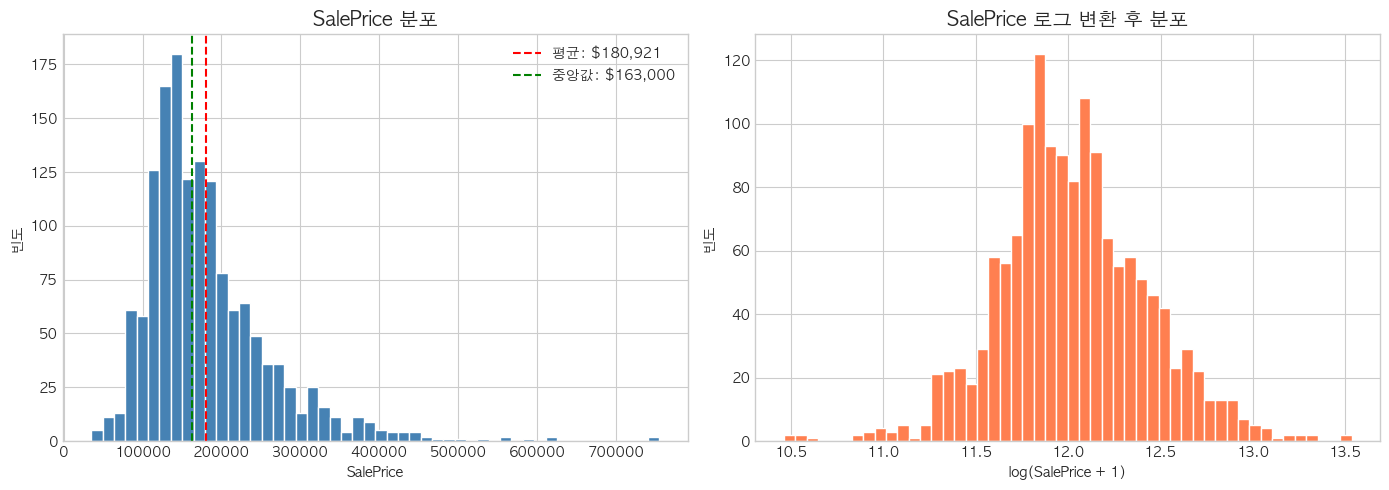


💡 인사이트: SalePrice는 오른쪽으로 치우친(right-skewed) 분포를 보입니다.
   로그 변환을 하면 정규분포에 가까워집니다!


In [8]:
# SalePrice 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice 분포', fontsize=14)
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('빈도')
axes[0].axvline(train['SalePrice'].mean(), color='red', linestyle='--', label=f'평균: ${train["SalePrice"].mean():,.0f}')
axes[0].axvline(train['SalePrice'].median(), color='green', linestyle='--', label=f'중앙값: ${train["SalePrice"].median():,.0f}')
axes[0].legend()

# 로그 변환 후 히스토그램
axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice 로그 변환 후 분포', fontsize=14)
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

print("\n💡 인사이트: SalePrice는 오른쪽으로 치우친(right-skewed) 분포를 보입니다.")
print("   로그 변환을 하면 정규분포에 가까워집니다!")

### 2.3 결측값(Missing Values) 분석

결측값이 많은 컬럼들을 확인해봅시다. 결측값 처리는 Feature Engineering에서 중요한 부분입니다!

In [9]:
# 결측값 확인
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    '결측값 수': missing,
    '결측률(%)': missing_percent.round(2)
})

print(f"📊 결측값이 있는 컬럼: {len(missing_df)}개\n")
missing_df

📊 결측값이 있는 컬럼: 19개



,결측값 수,결측률(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


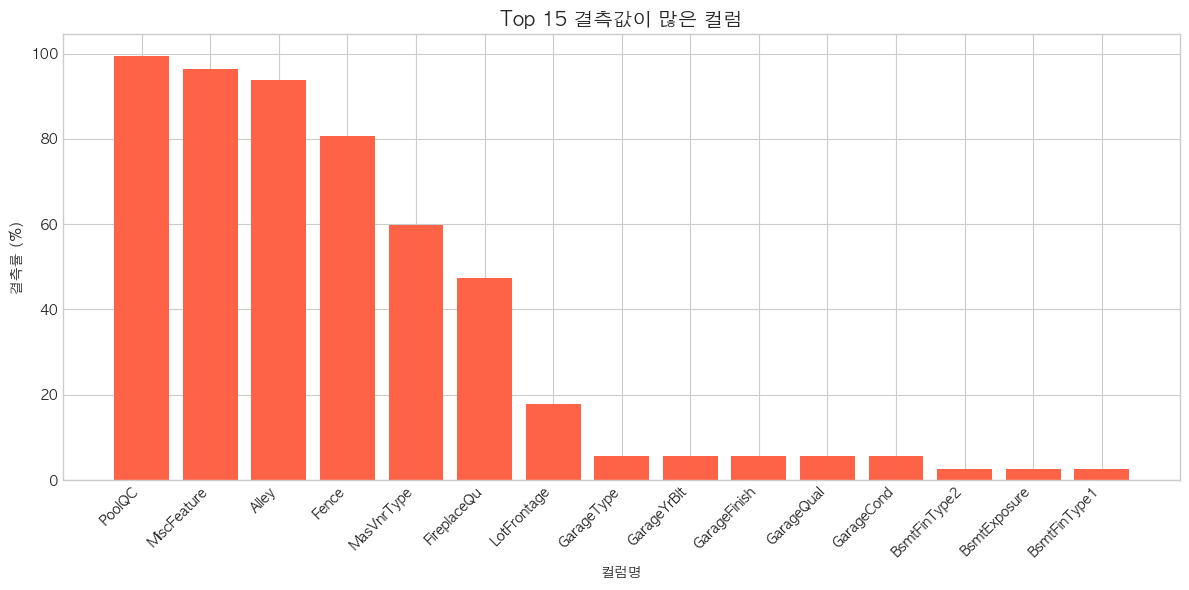


💡 인사이트: PoolQC, MiscFeature, Alley, Fence 등은 결측률이 매우 높습니다.
   이들은 '해당 시설 없음'을 의미하는 경우가 많습니다.


In [10]:
# 결측값 시각화
plt.figure(figsize=(12, 6))
plt.bar(missing_df.index[:15], missing_df['결측률(%)'][:15], color='tomato')
plt.title('Top 15 결측값이 많은 컬럼', fontsize=14)
plt.xlabel('컬럼명')
plt.ylabel('결측률 (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n💡 인사이트: PoolQC, MiscFeature, Alley, Fence 등은 결측률이 매우 높습니다.")
print("   이들은 '해당 시설 없음'을 의미하는 경우가 많습니다.")

### 2.4 상관관계(Correlation) 분석

어떤 특성들이 집 가격(`SalePrice`)과 높은 상관관계를 가지는지 확인해봅시다.

In [11]:
# 수치형 컬럼만 선택하여 상관관계 계산
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation = train[numeric_cols].corr()

# SalePrice와의 상관관계
sale_price_corr = correlation['SalePrice'].sort_values(ascending=False)
print("📊 SalePrice와의 상관관계 (Top 15):\n")
print(sale_price_corr.head(15))

📊 SalePrice와의 상관관계 (Top 15):

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


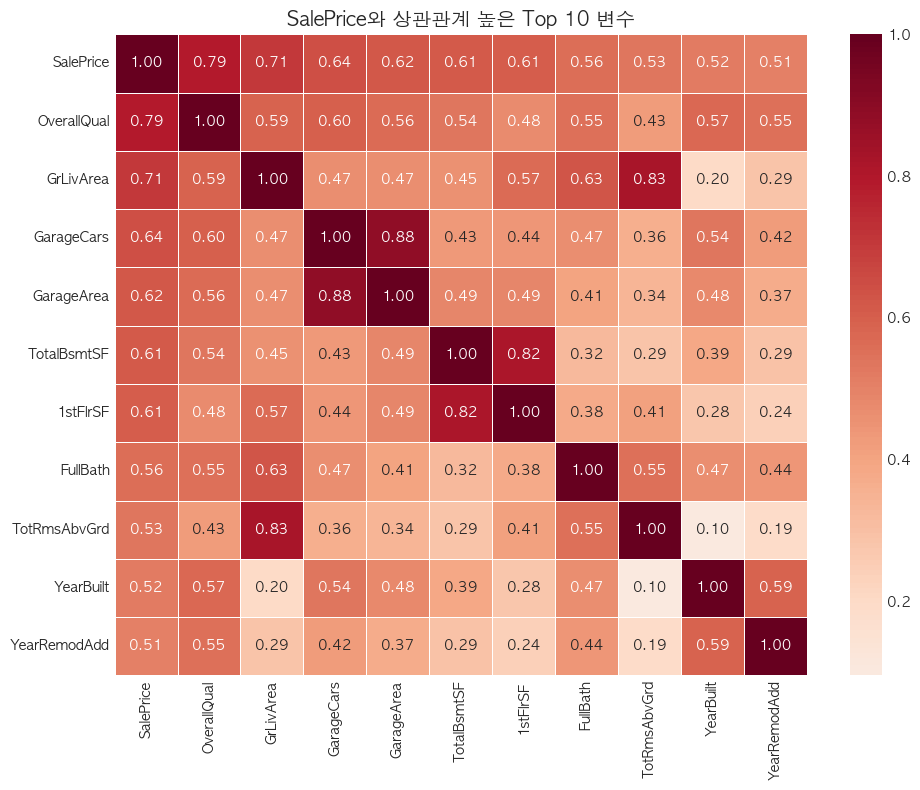


💡 인사이트:
   - OverallQual (전반적 품질): 가장 높은 상관관계!
   - GrLivArea (지상 면적): 면적이 클수록 가격이 높음
   - GarageCars/GarageArea: 차고 크기도 중요한 요소


In [12]:
# 상위 10개 변수의 상관관계 히트맵
top_corr_cols = sale_price_corr.head(11).index  # SalePrice 포함 11개

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_cols].corr(), annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('SalePrice와 상관관계 높은 Top 10 변수', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print("   - OverallQual (전반적 품질): 가장 높은 상관관계!")
print("   - GrLivArea (지상 면적): 면적이 클수록 가격이 높음")
print("   - GarageCars/GarageArea: 차고 크기도 중요한 요소")

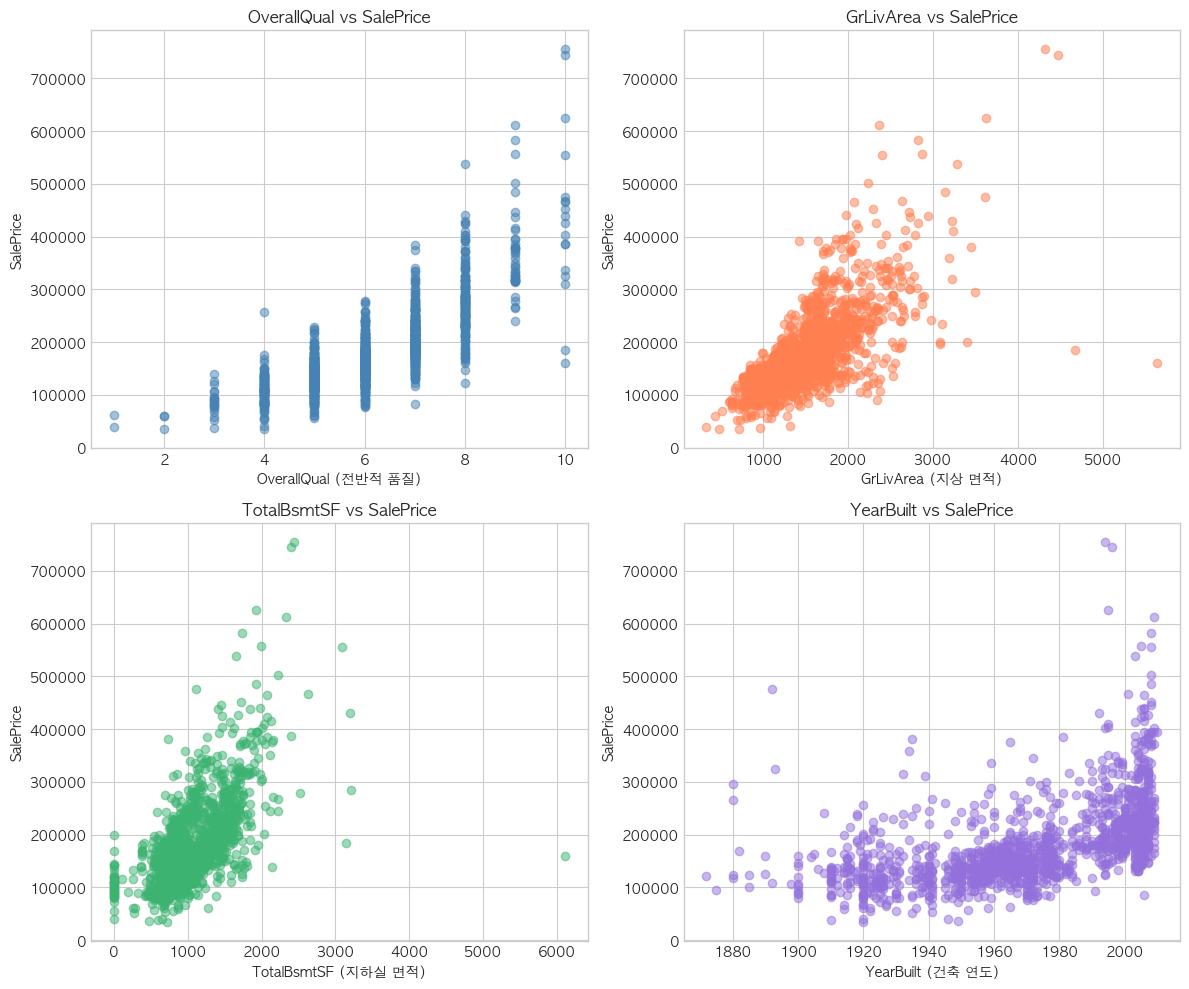


💡 인사이트:
   - 품질이 높을수록 가격이 선형적으로 증가
   - 면적과 가격은 양의 상관관계 (일부 이상치 존재)
   - 최근에 지어진 집일수록 가격이 높은 경향


In [13]:
# 주요 변수와 SalePrice 산점도
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# OverallQual vs SalePrice
axes[0, 0].scatter(train['OverallQual'], train['SalePrice'], alpha=0.5, color='steelblue')
axes[0, 0].set_title('OverallQual vs SalePrice')
axes[0, 0].set_xlabel('OverallQual (전반적 품질)')
axes[0, 0].set_ylabel('SalePrice')

# GrLivArea vs SalePrice
axes[0, 1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='coral')
axes[0, 1].set_title('GrLivArea vs SalePrice')
axes[0, 1].set_xlabel('GrLivArea (지상 면적)')
axes[0, 1].set_ylabel('SalePrice')

# TotalBsmtSF vs SalePrice
axes[1, 0].scatter(train['TotalBsmtSF'], train['SalePrice'], alpha=0.5, color='mediumseagreen')
axes[1, 0].set_title('TotalBsmtSF vs SalePrice')
axes[1, 0].set_xlabel('TotalBsmtSF (지하실 면적)')
axes[1, 0].set_ylabel('SalePrice')

# YearBuilt vs SalePrice
axes[1, 1].scatter(train['YearBuilt'], train['SalePrice'], alpha=0.5, color='mediumpurple')
axes[1, 1].set_title('YearBuilt vs SalePrice')
axes[1, 1].set_xlabel('YearBuilt (건축 연도)')
axes[1, 1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print("   - 품질이 높을수록 가격이 선형적으로 증가")
print("   - 면적과 가격은 양의 상관관계 (일부 이상치 존재)")
print("   - 최근에 지어진 집일수록 가격이 높은 경향")

---
## 3️⃣ 기본 모델 학습 (Baseline Model)

이제 간단한 전처리만으로 **베이스라인 모델**을 만들어봅시다.

> 🎯 **베이스라인의 목적**: 최소한의 노력으로 기준 성능을 확보하고, 이후 개선의 기준점으로 삼습니다.

### 3.1 간단한 데이터 전처리

In [14]:
# 필요한 라이브러리 임포트
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ ML 라이브러리 임포트 완료!")

✅ ML 라이브러리 임포트 완료!


In [15]:
# 베이스라인을 위한 간단한 전처리
# 1. 수치형 컬럼만 선택 (범주형은 나중에 처리)
# 2. 결측값을 중앙값으로 대체

# 타겟 변수 분리
y = train['SalePrice']

# 수치형 컬럼만 선택 (Id와 SalePrice 제외)
numeric_features = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Id')
numeric_features.remove('SalePrice')

print(f"📊 사용할 수치형 특성: {len(numeric_features)}개")
print(numeric_features[:10], "...")

📊 사용할 수치형 특성: 36개
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2'] ...


In [16]:
# 특성 데이터 준비
X_baseline = train[numeric_features].copy()

# 결측값을 중앙값으로 대체
X_baseline = X_baseline.fillna(X_baseline.median())

print(f"📊 특성 데이터 크기: {X_baseline.shape}")
print(f"📊 결측값 확인: {X_baseline.isnull().sum().sum()}개")

📊 특성 데이터 크기: (1460, 36)
📊 결측값 확인: 0개


In [17]:
# 학습/검증 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

print(f"📊 학습 데이터: {X_train.shape}")
print(f"📊 검증 데이터: {X_val.shape}")

📊 학습 데이터: (1168, 36)
📊 검증 데이터: (292, 36)


### 3.2 평가 함수 정의

Kaggle에서는 **RMSE (Root Mean Squared Error)**를 사용합니다.
더 정확하게는 log 변환된 값의 RMSE를 사용합니다.

In [20]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name="Model"):
    """모델 성능 평가 함수"""
    # 예측
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # ⚠️ 음수 예측값 처리 (집 가격은 음수가 될 수 없으므로 최소값 1로 클리핑)
    # Linear Regression 등은 음수를 예측할 수 있어서 log 변환 시 NaN 발생 방지
    y_train_pred = np.clip(y_train_pred, 1, None)
    y_val_pred = np.clip(y_val_pred, 1, None)
    
    # RMSE 계산 (로그 변환 후)
    train_rmse = np.sqrt(mean_squared_error(np.log1p(y_train), np.log1p(y_train_pred)))
    val_rmse = np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(y_val_pred)))
    
    # R2 Score
    val_r2 = r2_score(y_val, y_val_pred)
    
    print(f"📊 {model_name}")
    print(f"   Train RMSLE: {train_rmse:.4f}")
    print(f"   Val RMSLE:   {val_rmse:.4f}")
    print(f"   Val R² Score: {val_r2:.4f}")
    print()
    
    return val_rmse, val_r2

### 3.3 여러 모델 학습 및 비교

여러 회귀 모델을 학습하고 성능을 비교해봅시다.

In [21]:
# 베이스라인 결과를 저장할 딕셔너리
baseline_results = {}

print("=" * 50)
print("🚀 베이스라인 모델 학습 시작!")
print("=" * 50)
print()

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
rmse, r2 = evaluate_model(lr, X_train, X_val, y_train, y_val, "Linear Regression")
baseline_results['Linear Regression'] = {'rmse': rmse, 'r2': r2}

# 2. Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
rmse, r2 = evaluate_model(ridge, X_train, X_val, y_train, y_val, "Ridge Regression")
baseline_results['Ridge'] = {'rmse': rmse, 'r2': r2}

# 3. Lasso Regression
lasso = Lasso(alpha=100)
lasso.fit(X_train, y_train)
rmse, r2 = evaluate_model(lasso, X_train, X_val, y_train, y_val, "Lasso Regression")
baseline_results['Lasso'] = {'rmse': rmse, 'r2': r2}

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rmse, r2 = evaluate_model(rf, X_train, X_val, y_train, y_val, "Random Forest")
baseline_results['Random Forest'] = {'rmse': rmse, 'r2': r2}

# 5. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
rmse, r2 = evaluate_model(gb, X_train, X_val, y_train, y_val, "Gradient Boosting")
baseline_results['Gradient Boosting'] = {'rmse': rmse, 'r2': r2}

🚀 베이스라인 모델 학습 시작!

📊 Linear Regression
   Train RMSLE: 0.3601
   Val RMSLE:   0.1894
   Val R² Score: 0.8231

📊 Ridge Regression
   Train RMSLE: 0.3616
   Val RMSLE:   0.1892
   Val R² Score: 0.8232

📊 Lasso Regression
   Train RMSLE: 0.3574
   Val RMSLE:   0.1906
   Val R² Score: 0.8231

📊 Random Forest
   Train RMSLE: 0.0610
   Val RMSLE:   0.1551
   Val R² Score: 0.8856

📊 Gradient Boosting
   Train RMSLE: 0.0918
   Val RMSLE:   0.1436
   Val R² Score: 0.8937



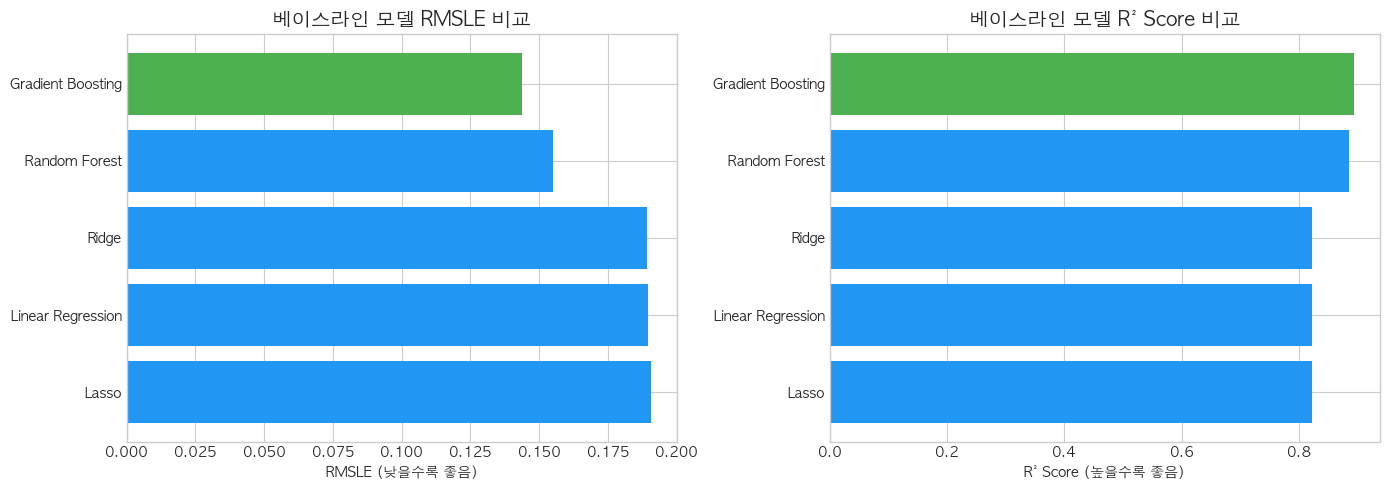


🏆 베이스라인 최고 성능 모델: Gradient Boosting
   RMSLE: 0.1436


In [22]:
# 베이스라인 결과 시각화
baseline_df = pd.DataFrame(baseline_results).T
baseline_df = baseline_df.sort_values('rmse')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 비교
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(baseline_df))]
axes[0].barh(baseline_df.index, baseline_df['rmse'], color=colors)
axes[0].set_xlabel('RMSLE (낮을수록 좋음)')
axes[0].set_title('베이스라인 모델 RMSLE 비교', fontsize=14)
axes[0].invert_yaxis()

# R² Score 비교
axes[1].barh(baseline_df.index, baseline_df['r2'], color=colors)
axes[1].set_xlabel('R² Score (높을수록 좋음)')
axes[1].set_title('베이스라인 모델 R² Score 비교', fontsize=14)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

best_model = baseline_df.index[0]
best_rmse = baseline_df.iloc[0]['rmse']
print(f"\n🏆 베이스라인 최고 성능 모델: {best_model}")
print(f"   RMSLE: {best_rmse:.4f}")

---
## 4️⃣ Feature Engineering (특성 공학)

이제 데이터를 가공하여 모델 성능을 향상시켜 봅시다!

> 🔧 **Feature Engineering이란?**
> - 원본 데이터에서 새로운 특성을 만들거나
> - 기존 특성을 변환하여
> - 모델이 더 잘 학습할 수 있도록 하는 과정

### 4.1 결측값 처리

In [23]:
# 원본 데이터 복사
train_fe = train.copy()

# 결측값 처리 함수
def fill_missing_values(df):
    """도메인 지식을 활용한 결측값 처리"""
    df = df.copy()
    
    # 1. 시설이 없음을 의미하는 결측값 -> 'None' 또는 0으로 처리
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'MasVnrType']
    
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    
    # 2. 수치형 결측값 처리
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
                 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
                 'BsmtHalfBath', 'MasVnrArea']
    
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # 3. 최빈값으로 처리
    mode_cols = ['Electrical', 'MSZoning', 'Functional', 'Utilities', 
                 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'SaleType']
    
    for col in mode_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'None')
    
    # 4. 중앙값으로 처리 (나머지 수치형)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # 5. 나머지 범주형 -> 'None'
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna('None')
    
    return df

train_fe = fill_missing_values(train_fe)

print(f"✅ 결측값 처리 완료!")
print(f"   남은 결측값: {train_fe.isnull().sum().sum()}개")

✅ 결측값 처리 완료!
   남은 결측값: 0개


### 4.2 새로운 특성 생성

도메인 지식을 활용하여 의미 있는 새로운 특성을 만들어봅시다!

In [24]:
def create_features(df):
    """새로운 특성 생성"""
    df = df.copy()
    
    # 1. 총 면적 관련 특성
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['TotalBathrooms'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    
    # 2. 집 나이 관련 특성
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew'] = (df['YrSold'] == df['YearBuilt']).astype(int)
    
    # 3. 품질 관련 특성
    df['OverallScore'] = df['OverallQual'] * df['OverallCond']
    
    # 4. 차고 관련 특성
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
    df['GarageAge'] = df['GarageAge'].apply(lambda x: 0 if x < 0 else x)
    
    # 5. 지하실 관련 특성
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['BsmtFinRatio'] = df['BsmtFinSF1'] / (df['TotalBsmtSF'] + 1)  # +1 to avoid division by zero
    
    # 6. 수영장, 벽난로 여부
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    
    # 7. 방 관련 특성
    df['TotalRooms'] = df['TotRmsAbvGrd'] + df['FullBath'] + df['HalfBath']
    df['AvgRoomSize'] = df['GrLivArea'] / (df['TotRmsAbvGrd'] + 1)
    
    return df

train_fe = create_features(train_fe)

print("✅ 새로운 특성 생성 완료!")
print(f"\n📊 생성된 새로운 특성들:")
new_features = ['TotalSF', 'TotalPorchSF', 'TotalBathrooms', 'HouseAge', 'RemodAge', 
                'IsRemodeled', 'IsNew', 'OverallScore', 'HasGarage', 'GarageAge',
                'HasBasement', 'BsmtFinRatio', 'HasPool', 'HasFireplace', 'TotalRooms', 'AvgRoomSize']
for feat in new_features:
    print(f"   - {feat}")

✅ 새로운 특성 생성 완료!

📊 생성된 새로운 특성들:
   - TotalSF
   - TotalPorchSF
   - TotalBathrooms
   - HouseAge
   - RemodAge
   - IsRemodeled
   - IsNew
   - OverallScore
   - HasGarage
   - GarageAge
   - HasBasement
   - BsmtFinRatio
   - HasPool
   - HasFireplace
   - TotalRooms
   - AvgRoomSize


### 4.3 범주형 변수 인코딩

범주형(카테고리) 변수를 숫자로 변환해야 머신러닝 모델이 학습할 수 있습니다.

- **Label Encoding**: 순서가 있는 범주형 (품질 등급 등)
- **One-Hot Encoding**: 순서가 없는 범주형 (지역명 등)

In [25]:
# 순서형 변수 매핑 (품질 등급 등)
quality_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
finish_mapping = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
exposure_mapping = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
garage_finish_mapping = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

# 품질 관련 컬럼 인코딩
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].map(quality_mapping).fillna(0)

# 기타 순서형 컬럼 인코딩
if 'BsmtFinType1' in train_fe.columns:
    train_fe['BsmtFinType1'] = train_fe['BsmtFinType1'].map(finish_mapping).fillna(0)
if 'BsmtFinType2' in train_fe.columns:
    train_fe['BsmtFinType2'] = train_fe['BsmtFinType2'].map(finish_mapping).fillna(0)
if 'BsmtExposure' in train_fe.columns:
    train_fe['BsmtExposure'] = train_fe['BsmtExposure'].map(exposure_mapping).fillna(0)
if 'GarageFinish' in train_fe.columns:
    train_fe['GarageFinish'] = train_fe['GarageFinish'].map(garage_finish_mapping).fillna(0)

print("✅ 순서형 변수 인코딩 완료!")

✅ 순서형 변수 인코딩 완료!


In [26]:
# 나머지 범주형 변수 One-Hot Encoding
categorical_cols = train_fe.select_dtypes(include=['object']).columns.tolist()
print(f"📊 One-Hot Encoding 대상: {len(categorical_cols)}개 컬럼")

# One-Hot Encoding 적용
train_encoded = pd.get_dummies(train_fe, columns=categorical_cols, drop_first=True)

print(f"\n✅ One-Hot Encoding 완료!")
print(f"   인코딩 전 컬럼 수: {len(train_fe.columns)}")
print(f"   인코딩 후 컬럼 수: {len(train_encoded.columns)}")

📊 One-Hot Encoding 대상: 29개 컬럼

✅ One-Hot Encoding 완료!
   인코딩 전 컬럼 수: 97
   인코딩 후 컬럼 수: 232


### 4.4 이상치(Outlier) 제거

EDA에서 발견한 이상치를 제거하여 모델 성능을 향상시킵니다.

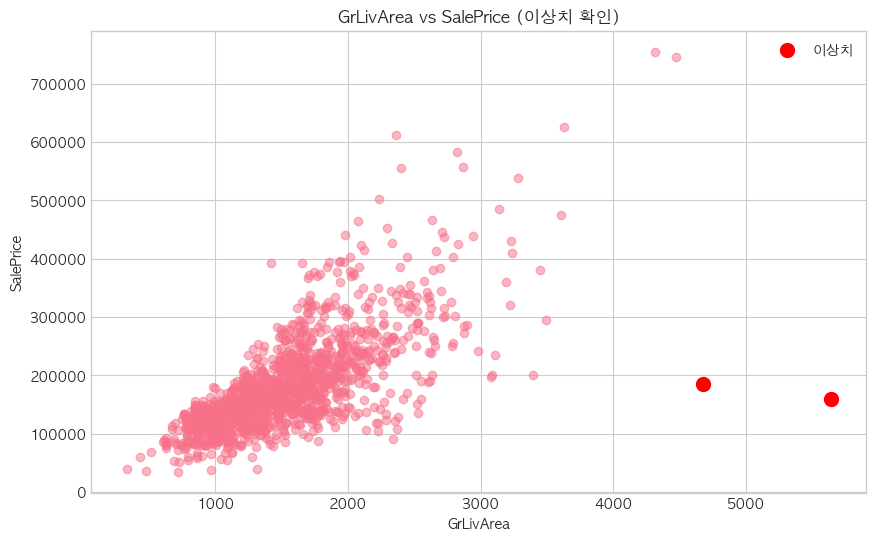

🔍 발견된 이상치: 2개


In [27]:
# GrLivArea가 매우 큰데 가격이 낮은 이상치 제거
plt.figure(figsize=(10, 6))
plt.scatter(train_encoded['GrLivArea'], train_encoded['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice (이상치 확인)')

# 이상치 표시
outliers = train_encoded[(train_encoded['GrLivArea'] > 4000) & (train_encoded['SalePrice'] < 300000)]
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=100, label='이상치')
plt.legend()
plt.show()

print(f"🔍 발견된 이상치: {len(outliers)}개")

In [28]:
# 이상치 제거
train_clean = train_encoded[~((train_encoded['GrLivArea'] > 4000) & (train_encoded['SalePrice'] < 300000))]

print(f"✅ 이상치 제거 완료!")
print(f"   제거 전: {len(train_encoded)}개")
print(f"   제거 후: {len(train_clean)}개")

✅ 이상치 제거 완료!
   제거 전: 1460개
   제거 후: 1458개


---
## 5️⃣ 개선된 모델 학습 및 비교

Feature Engineering을 적용한 데이터로 다시 모델을 학습하고, 
베이스라인과 성능을 비교해봅시다!

### 5.1 데이터 준비

In [29]:
# Feature Engineering 적용된 데이터로 학습/검증 분할
y_fe = train_clean['SalePrice']
X_fe = train_clean.drop(['Id', 'SalePrice'], axis=1)

# 학습/검증 분할
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

print(f"📊 Feature Engineering 적용 후:")
print(f"   학습 데이터: {X_train_fe.shape}")
print(f"   검증 데이터: {X_val_fe.shape}")
print(f"   총 특성 수: {X_train_fe.shape[1]}개 (베이스라인: {len(numeric_features)}개)")

📊 Feature Engineering 적용 후:
   학습 데이터: (1166, 230)
   검증 데이터: (292, 230)
   총 특성 수: 230개 (베이스라인: 36개)


### 5.2 개선된 모델 학습

In [30]:
# 개선된 결과를 저장할 딕셔너리
improved_results = {}

print("=" * 50)
print("🚀 Feature Engineering 적용 모델 학습 시작!")
print("=" * 50)
print()

# 1. Ridge Regression
ridge_fe = Ridge(alpha=10)
ridge_fe.fit(X_train_fe, y_train_fe)
rmse, r2 = evaluate_model(ridge_fe, X_train_fe, X_val_fe, y_train_fe, y_val_fe, "Ridge Regression (FE)")
improved_results['Ridge'] = {'rmse': rmse, 'r2': r2}

# 2. Lasso Regression
lasso_fe = Lasso(alpha=100)
lasso_fe.fit(X_train_fe, y_train_fe)
rmse, r2 = evaluate_model(lasso_fe, X_train_fe, X_val_fe, y_train_fe, y_val_fe, "Lasso Regression (FE)")
improved_results['Lasso'] = {'rmse': rmse, 'r2': r2}

# 3. Random Forest
rf_fe = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_fe.fit(X_train_fe, y_train_fe)
rmse, r2 = evaluate_model(rf_fe, X_train_fe, X_val_fe, y_train_fe, y_val_fe, "Random Forest (FE)")
improved_results['Random Forest'] = {'rmse': rmse, 'r2': r2}

# 4. Gradient Boosting
gb_fe = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb_fe.fit(X_train_fe, y_train_fe)
rmse, r2 = evaluate_model(gb_fe, X_train_fe, X_val_fe, y_train_fe, y_val_fe, "Gradient Boosting (FE)")
improved_results['Gradient Boosting'] = {'rmse': rmse, 'r2': r2}

🚀 Feature Engineering 적용 모델 학습 시작!

📊 Ridge Regression (FE)
   Train RMSLE: 0.1208
   Val RMSLE:   0.1504
   Val R² Score: 0.8868

📊 Lasso Regression (FE)
   Train RMSLE: 0.1227
   Val RMSLE:   0.1472
   Val R² Score: 0.8886

📊 Random Forest (FE)
   Train RMSLE: 0.0534
   Val RMSLE:   0.1455
   Val R² Score: 0.8930

📊 Gradient Boosting (FE)
   Train RMSLE: 0.0429
   Val RMSLE:   0.1299
   Val R² Score: 0.9102



### 5.3 베이스라인 vs 개선 모델 비교

Feature Engineering 전후의 성능을 비교해봅시다!

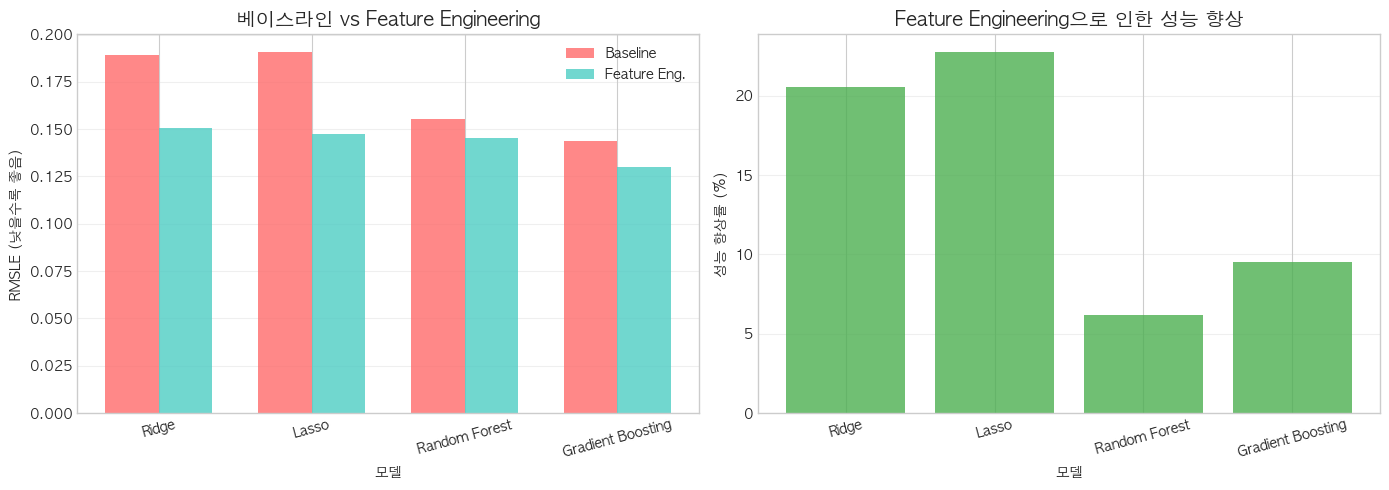

In [31]:
# 비교 데이터 준비
models = ['Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting']
baseline_rmse = [baseline_results[m]['rmse'] for m in models]
improved_rmse = [improved_results[m]['rmse'] for m in models]

# 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 비교
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, baseline_rmse, width, label='Baseline', color='#FF6B6B', alpha=0.8)
bars2 = axes[0].bar(x + width/2, improved_rmse, width, label='Feature Eng.', color='#4ECDC4', alpha=0.8)

axes[0].set_xlabel('모델')
axes[0].set_ylabel('RMSLE (낮을수록 좋음)')
axes[0].set_title('베이스라인 vs Feature Engineering', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 성능 향상률
improvement = [(b - i) / b * 100 for b, i in zip(baseline_rmse, improved_rmse)]
colors = ['#4CAF50' if imp > 0 else '#F44336' for imp in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.8)
axes[1].set_xlabel('모델')
axes[1].set_ylabel('성능 향상률 (%)')
axes[1].set_title('Feature Engineering으로 인한 성능 향상', fontsize=14)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [32]:
# 성능 비교 테이블 출력
comparison_data = []
for model in models:
    comparison_data.append({
        '모델': model,
        'Baseline RMSLE': f"{baseline_results[model]['rmse']:.4f}",
        'FE RMSLE': f"{improved_results[model]['rmse']:.4f}",
        '향상률': f"{(baseline_results[model]['rmse'] - improved_results[model]['rmse']) / baseline_results[model]['rmse'] * 100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print("📊 성능 비교 테이블:\n")
print(comparison_df.to_string(index=False))

# 최고 성능 모델 찾기
best_model_name = min(improved_results, key=lambda x: improved_results[x]['rmse'])
best_rmse = improved_results[best_model_name]['rmse']
baseline_best_rmse = baseline_results[best_model_name]['rmse']

print(f"\n🏆 최고 성능 모델: {best_model_name}")
print(f"   베이스라인 RMSLE: {baseline_best_rmse:.4f}")
print(f"   개선 후 RMSLE: {best_rmse:.4f}")
print(f"   성능 향상: {(baseline_best_rmse - best_rmse) / baseline_best_rmse * 100:.2f}%")

📊 성능 비교 테이블:

               모델 Baseline RMSLE FE RMSLE    향상률
            Ridge         0.1892   0.1504 20.54%
            Lasso         0.1906   0.1472 22.74%
    Random Forest         0.1551   0.1455  6.18%
Gradient Boosting         0.1436   0.1299  9.54%

🏆 최고 성능 모델: Gradient Boosting
   베이스라인 RMSLE: 0.1436
   개선 후 RMSLE: 0.1299
   성능 향상: 9.54%


### 5.4 Feature Importance (특성 중요도)

어떤 특성이 모델 예측에 가장 큰 영향을 미쳤는지 확인해봅시다.

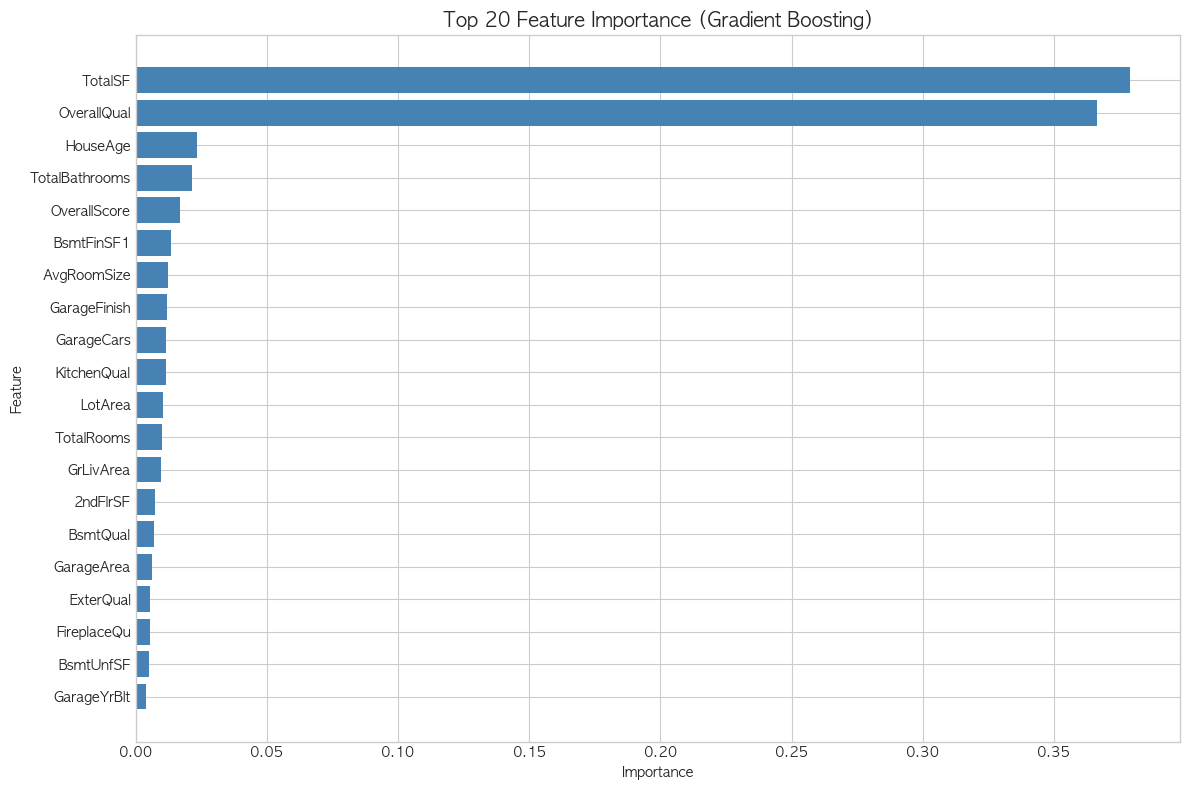


💡 인사이트:
   - 우리가 만든 특성들(TotalSF, TotalBathrooms 등)이 중요도 상위에 있습니다!
   - Feature Engineering이 효과가 있었음을 확인할 수 있습니다.


In [33]:
# Gradient Boosting 모델의 Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': gb_fe.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 특성 시각화
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance (Gradient Boosting)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print("   - 우리가 만든 특성들(TotalSF, TotalBathrooms 등)이 중요도 상위에 있습니다!")
print("   - Feature Engineering이 효과가 있었음을 확인할 수 있습니다.")

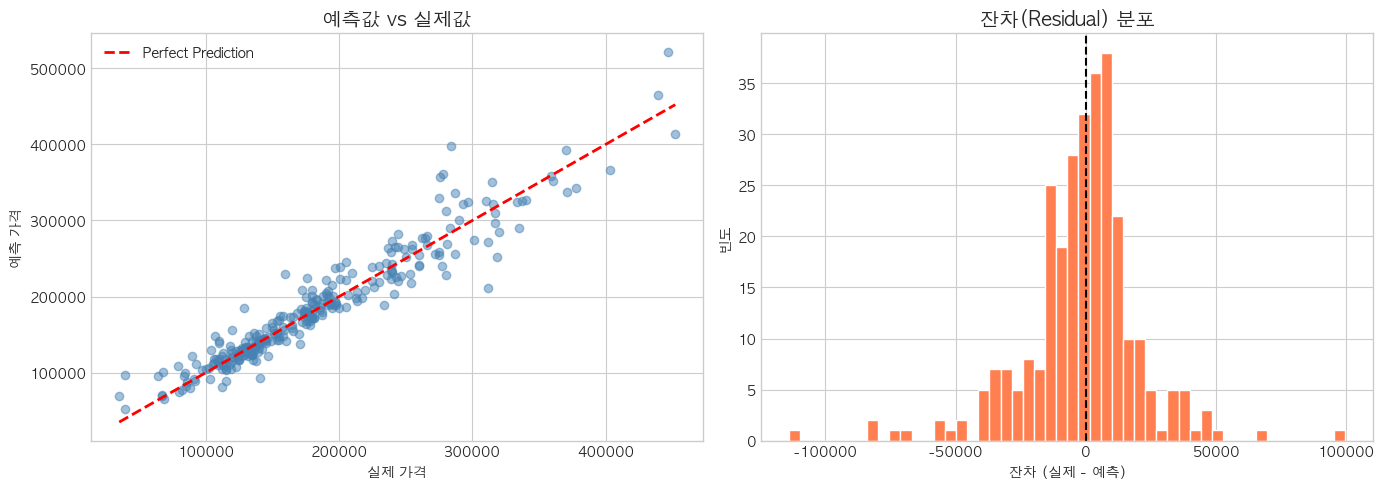


📊 검증 데이터 예측 결과:
   평균 절대 오차 (MAE): $15,117
   평균 가격: $181,369
   오차 비율: 8.3%


In [34]:
# 예측값 vs 실제값 시각화
y_pred = gb_fe.predict(X_val_fe)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도
axes[0].scatter(y_val_fe, y_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_val_fe.min(), y_val_fe.max()], [y_val_fe.min(), y_val_fe.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('실제 가격')
axes[0].set_ylabel('예측 가격')
axes[0].set_title('예측값 vs 실제값', fontsize=14)
axes[0].legend()

# 잔차 분포
residuals = y_val_fe - y_pred
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title('잔차(Residual) 분포', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\n📊 검증 데이터 예측 결과:")
print(f"   평균 절대 오차 (MAE): ${np.mean(np.abs(residuals)):,.0f}")
print(f"   평균 가격: ${y_val_fe.mean():,.0f}")
print(f"   오차 비율: {np.mean(np.abs(residuals)) / y_val_fe.mean() * 100:.1f}%")

<div style="margin:20px 0 4px;padding:14px 20px;border-radius:10px;background:#F4E7DF;border:1px solid #E7DCC6;">
<span style="font-size:19px;font-weight:800;color:#23211C;">✏️ 직접 풀어 보기 — 연습문제</span><br>
<span style="color:#5A5448;font-size:14px;line-height:1.7;">아래 문제를 먼저 <b>스스로</b> 채워 본 뒤 <b>정답 노트북</b>과 비교하세요. 위에서 만든 변수(<code>train</code>, <code>X_train</code>, <code>evaluate_model</code>, <code>gb_fe</code> 등)를 그대로 씁니다. 막히면 위쪽 해당 셀을 참고하세요.</span>
</div>

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 1 상관관계 직접 확인</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>GarageCars</code>(차고 수)와 <code>SalePrice</code>의 <b>상관계수</b>를 구하고, <code>GarageCars</code> 값별 <b>평균 SalePrice</b>를 출력하세요.<br>
<b>힌트</b> &nbsp; <code>df[['A','B']].corr()</code> · <code>df.groupby('열')['SalePrice'].mean()</code><br>
<b>예상</b> &nbsp; 상관계수 약 0.64 · 차고가 많을수록 평균 가격↑
</div>
</div>

In [ ]:
# ✏️ 연습문제 1 — 빈칸(____)을 채워 보세요
# 1) GarageCars 와 SalePrice 의 상관계수
print(train[['GarageCars', 'SalePrice']].____())     # 힌트: 상관계수 메서드

# 2) GarageCars 값별 평균 SalePrice
print(train.groupby('____')['SalePrice'].____())      # 힌트: 그룹별 평균

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 2 새 특성 만들기 (집 나이)</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>YrSold</code>(판 연도) − <code>YearBuilt</code>(지은 연도)로 <b>집 나이(<code>HouseAge</code>)</b> 특성을 만들고, <code>SalePrice</code>와의 상관계수를 확인하세요.<br>
<b>힌트</b> &nbsp; 두 열을 빼서 새 열에 저장: <code>df['새열'] = df['A'] - df['B']</code><br>
<b>예상</b> &nbsp; 음(−)의 상관 — 오래된 집일수록 대체로 싸다
</div>
</div>

In [ ]:
# ✏️ 연습문제 2 — 빈칸을 채워 보세요
train['HouseAge'] = train['____'] - train['____']     # 판 연도 - 지은 연도
print(train[['HouseAge', 'SalePrice']].corr())

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 3 모델 하나 더 비교 (결정 트리) <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>DecisionTreeRegressor</code>를 baseline 데이터로 학습·평가해 위 표와 견줘 보세요.<br>
<b>힌트</b> &nbsp; 먼저 <code>모델.fit(X_train, y_train)</code> 학습 후 <code>evaluate_model(모델, X_train, X_val, y_train, y_val, "이름")</code> 활용 · 트리는 <code>random_state=42</code><br>
<b>예상</b> &nbsp; 트리 단일 모델이라 RMSLE가 다소 높게 나온다
</div>
</div>

In [ ]:
# ✏️ 직접 작성 — DecisionTreeRegressor 를 baseline 데이터로 학습하고 evaluate_model 로 평가


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 4 한 채 예측 vs 실제 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 개선 모델 <code>gb_fe</code>로 검증셋 첫 번째 집의 <b>예측 가격</b>과 <b>실제 가격</b>(<code>y_val_fe</code>)을 출력하세요.<br>
<b>힌트</b> &nbsp; 한 채는 2차원 유지 <code>X_val_fe.iloc[[0]]</code><br>
<b>예상</b> &nbsp; 두 값이 비슷하면 성공
</div>
</div>

In [ ]:
# ✏️ 직접 작성 — gb_fe 로 첫 번째 집 예측 가격과 실제 가격(y_val_fe) 출력


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">🎯 종합문제 품질 등급과 가격의 관계 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">종합</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>OverallQual</code>(품질 등급)별 <b>평균 SalePrice</b>를 구해 <b>막대그래프</b>로 그리고, 가장 비싼 등급과 가장 싼 등급의 <b>가격 차이</b>를 출력하세요.<br>
<b>예상</b> &nbsp; 등급이 오를수록 평균 가격이 계단처럼 오르는 그래프
</div>
</div>

In [ ]:
# ✏️ 종합문제 — 처음부터 직접 작성해 보세요


---
## 6️⃣ 결론 및 다음 단계

### 📝 오늘 배운 내용

1. **EDA (탐색적 데이터 분석)**
   - 데이터의 기본 통계량 확인
   - 타겟 변수의 분포 분석
   - 결측값 확인 및 상관관계 분석

2. **베이스라인 모델**
   - 최소한의 전처리로 빠르게 기준 성능 확보
   - 여러 모델 비교

3. **Feature Engineering**
   - 도메인 지식을 활용한 결측값 처리
   - 새로운 의미 있는 특성 생성
   - 범주형 변수 인코딩
   - 이상치 제거

4. **성능 향상**
   - Feature Engineering을 통한 모델 성능 개선 확인

---

### 🚀 더 나아가기 (심화 학습)

다음 단계로 시도해볼 수 있는 것들:

1. **하이퍼파라미터 튜닝**: GridSearchCV, RandomizedSearchCV
2. **앙상블 기법**: Stacking, Blending
3. **고급 모델**: XGBoost, LightGBM, CatBoost
4. **교차 검증**: K-Fold Cross Validation
5. **타겟 변수 변환**: Log 변환 후 학습

---

### 💡 핵심 교훈

> **"데이터 이해가 모델 성능의 시작입니다!"**
> 
> Feature Engineering은 단순히 기술이 아니라, 데이터를 깊이 이해하고
> 도메인 지식을 활용하는 과정입니다.

---

축하합니다! 🎉 첫 번째 머신러닝 프로젝트를 완료했습니다!